<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Validação Cruzada, Pipeline e GridSearch


## Validação Cruzada

Técnica utilizada para avaliar a capacidade de generalização de um modelo de aprendizado de máquina.

O objetivo da validação cruzada é dividir o conjunto de dados em várias partes (folds) e treinar/testar o modelo várias vezes, alternando os conjuntos de treino e teste.

## Principais Técnicas de Validação Cruzada

* K-Fold

* Stratied K-Fold

* Leave-one-Out

* Repeated K-Fold

* Time Series Split




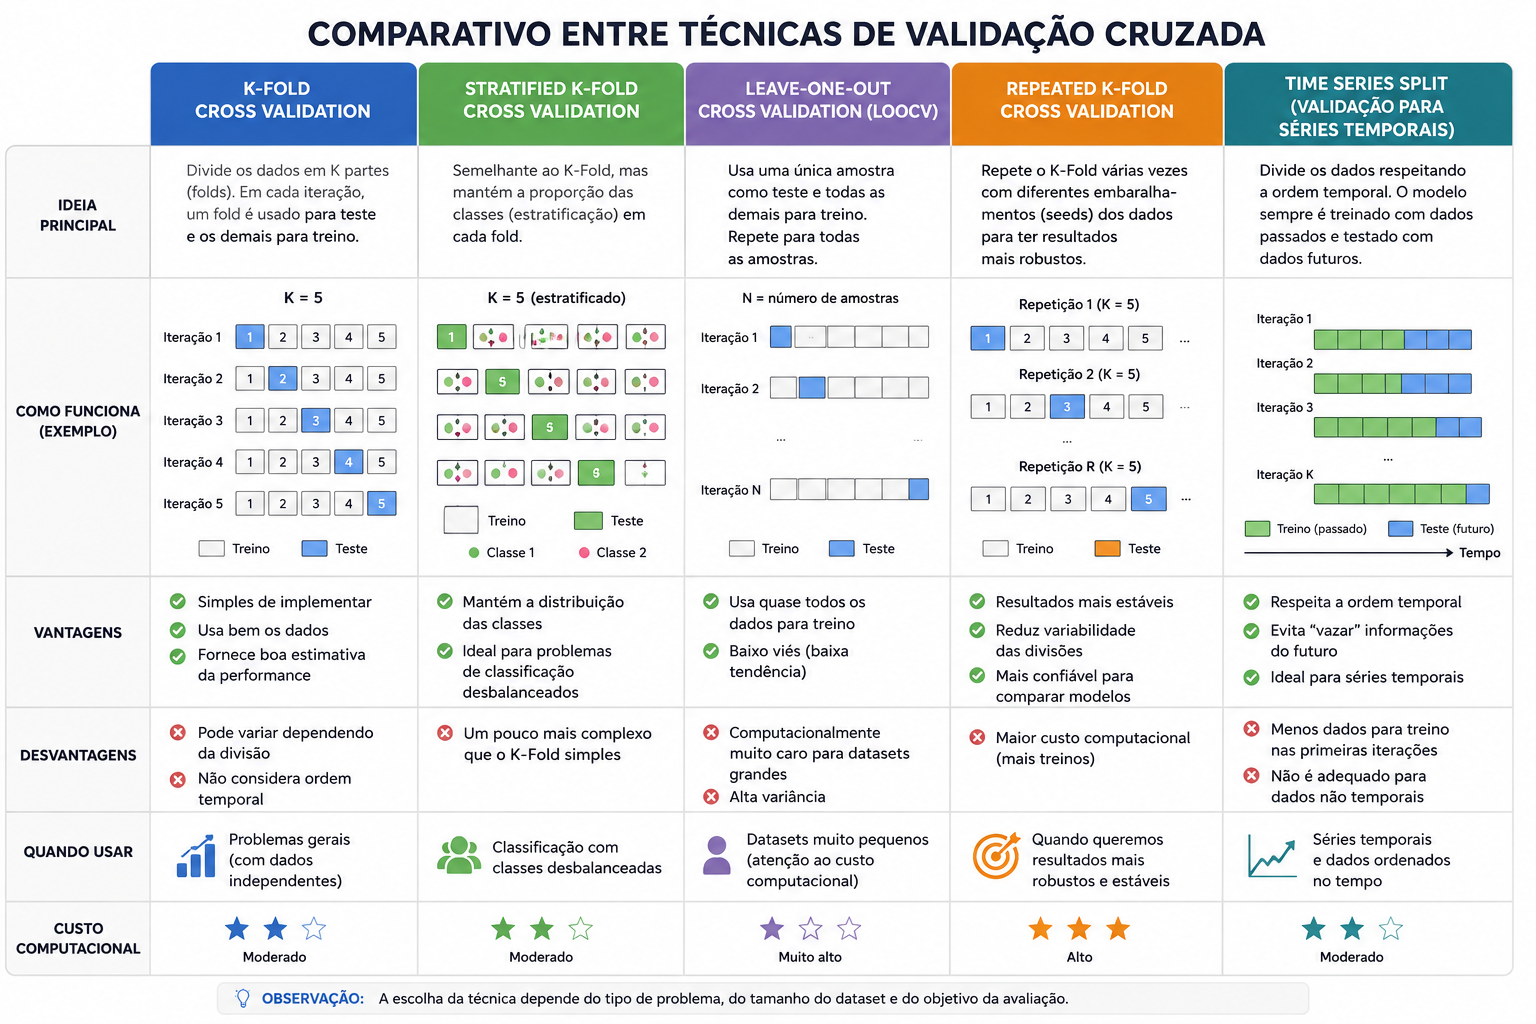

## Quando Utilizar a Validação Cruzada

* Quando o dataset é pequeno ou médio.

* Quando há a necessidade de comparar modelos.

* Necessitar de uma estimativa mais robusta.

* Quando estiver ajustando hiperparâmetros.

Se o dataset for muito grande a melhor estratégia é a de hold-out, seja, separar os dados de treino, de teste e de validação do modelo.

## Exemplo de Validação Cruzada (classificação)

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [6]:
dados = load_breast_cancer()
X = dados.data
y = dados.target

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

vc = cross_val_score(knn, X, y, cv = 5)

In [13]:
# Acurácia em cada um dos K-Folds
vc

array([0.88596491, 0.93859649, 0.93859649, 0.94736842, 0.92920354])

In [12]:
# Média das Acurácia
vc.mean()

np.float64(0.9279459711224964)

## Pipeline

O pipeline é uma forma de encadear etapas de pré-processamento e treinamento em um único objeto.

## Exemplo Pipeline

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [18]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state=42)

In [19]:
# Pipeline
pipeline = Pipeline([('padronizacao', StandardScaler()), ('modelo', KNeighborsClassifier(n_neighbors=5))])

In [21]:
# Treinamento
pipeline.fit(X_treino, y_treino)

# Teste
y_pred = pipeline.predict(X_teste)

In [24]:
# Classification report
print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        54
           1       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



## GridSearch

Técnica usada para encontrar automaticamente os melhores hiperparâmetros de um modelo.

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
# Exemplo para encontrar o melhor K para o KNN
valores_k = [1, 3, 5, 7]

knn = KNeighborsClassifier()

In [29]:
# Grid Search
parametros = {'n_neighbors': valores_k}
grid = GridSearchCV(knn, parametros, cv=5, scoring='accuracy')

In [30]:
grid.fit(X_treino, y_treino)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 7]}, scoring='accuracy')

In [31]:
grid.best_estimator_

KNeighborsClassifier(n_neighbors=7)

In [33]:
grid.best_params_

{'n_neighbors': 7}

In [32]:
grid.best_score_

np.float64(0.924733242134063)

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.